In [2]:
!pip install pandas scikit-learn cryptography matplotlib

In [3]:
import pandas as pd
import numpy as np
import pickle
import random
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from cryptography.fernet import Fernet

In [4]:
# Generate key (run once)
key = Fernet.generate_key()

with open("secret.key", "wb") as f:
    f.write(key)

# Load key
def load_key():
    return open("secret.key", "rb").read()

cipher = Fernet(load_key())

In [5]:
data = {
    "soil": ["Laterite","Red","Clay","Laterite","Red","Clay","Laterite","Red","Clay","Laterite"],
    "temperature": [28,30,32,27,29,33,26,31,34,28],
    "humidity": [85,80,78,88,82,75,90,79,77,86],
    "rainfall": [200,180,820,560,900,140,775,625,518,260],
    "disease": [
        "Healthy","Yellow_Leaf","Bud_Rot","Healthy","Yellow_Leaf",
        "Bud_Rot","koleroga","Bud_Rot","Yellow_Leaf","Healthy"
    ]
}

df = pd.DataFrame(data)

In [6]:
data_bytes = df.to_csv(index=False).encode()
encrypted_data = cipher.encrypt(data_bytes)

with open("dataset.enc", "wb") as f:
    f.write(encrypted_data)

print("✅ Dataset encrypted")

✅ Dataset encrypted


In [7]:
with open("dataset.enc", "rb") as f:
    enc = f.read()

dec = cipher.decrypt(enc)

from io import StringIO
df = pd.read_csv(StringIO(dec.decode()))

In [8]:
le_soil = LabelEncoder()
df["soil"] = le_soil.fit_transform(df["soil"])

le_disease = LabelEncoder()
df["disease"] = le_disease.fit_transform(df["disease"])

In [9]:
X = df[["soil","temperature","humidity","rainfall"]]
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pickle.dump(model, open("model.pkl","wb"))

print("✅ Model trained")

✅ Model trained


In [10]:
crop_info = {
    "Arecanut": {
        "diseases": {
            "Yellow_Leaf": "Apply micronutrients (Zinc, Magnesium)",
            "Bud_Rot": "Use fungicide and improve drainage",
            "Healthy": "No issue, maintain regular care",
            "koleroga": "Use fungicide and improve drainage"
        }
    }
}

In [11]:
def predict_with_prob(soil, temp, humidity, rainfall):

    soil_enc = le_soil.transform([soil])[0]
    input_data = np.array([[soil_enc, temp, humidity, rainfall]])

    model = pickle.load(open("model.pkl","rb"))

    probs = model.predict_proba(input_data)[0]
    classes = le_disease.inverse_transform(range(len(probs)))

    idx = np.argmax(probs)
    disease = classes[idx]

    solution = crop_info["Arecanut"]["diseases"][disease]

    return disease, solution, classes, probs

In [14]:

def random_input():
    return {
        "soil": random.choice(soils),
        "temp": random.randint(25,35),
        "humidity": random.randint(70,95),
        "rainfall": random.randint(120,250)
    }

results = []

for i in range(10):
    inp = random_input()

    disease, solution, classes, probs = predict_with_prob(
        inp["soil"], inp["temp"], inp["humidity"], inp["rainfall"]
    )

    results.append({
        "Soil": inp["soil"],
        "Temperature": inp["temp"],
        "Humidity": inp["humidity"],
        "Rainfall": inp["rainfall"],
        "Disease": disease,
        "Solution": solution
    })

df_results = pd.DataFrame(results)
print(df_results)

       Soil  Temperature  Humidity  Rainfall      Disease  \
0  Laterite           34        92       219  Yellow_Leaf   
1       Red           35        89       212  Yellow_Leaf   
2      Clay           32        87       146      Healthy   
3      Clay           34        92       224  Yellow_Leaf   
4      Clay           29        87       136      Healthy   
5      Clay           26        95       175      Healthy   
6       Red           28        88       190      Healthy   
7      Clay           35        80       158  Yellow_Leaf   
8       Red           35        95       142  Yellow_Leaf   
9       Red           28        72       245  Yellow_Leaf   

                                 Solution  
0  Apply micronutrients (Zinc, Magnesium)  
1  Apply micronutrients (Zinc, Magnesium)  
2         No issue, maintain regular care  
3  Apply micronutrients (Zinc, Magnesium)  
4         No issue, maintain regular care  
5         No issue, maintain regular care  
6         No issue, 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [15]:
data_bytes = df_results.to_csv(index=False).encode()
enc_out = cipher.encrypt(data_bytes)

with open("output.enc","wb") as f:
    f.write(enc_out)

print("✅ Output saved securely")

✅ Output saved securely


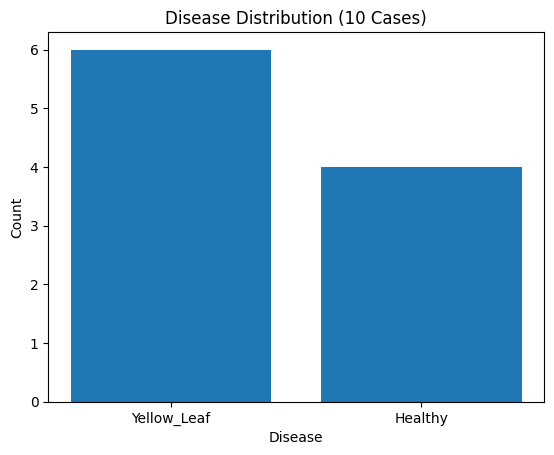

In [16]:
counts = df_results["Disease"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)

plt.title("Disease Distribution (10 Cases)")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


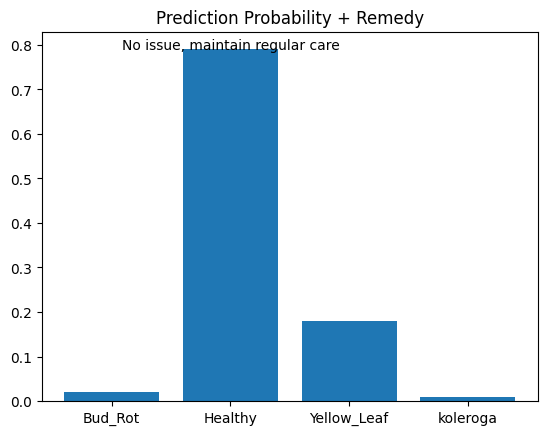

In [17]:
plt.figure()

disease, solution, classes, probs = predict_with_prob("Laterite", 29, 85, 210)

plt.bar(classes, probs)

idx = list(classes).index(disease)

plt.text(idx, probs[idx], f"\n{solution}", ha='center')

plt.title("Prediction Probability + Remedy")

plt.show()

In [ ]:
soils = ["Laterite","Red","Clay"]

def get_user_input():
    print("\nPlease enter the following details:")

    # Get soil type input with validation
    valid_soils_lower = [s.lower() for s in soils]
    while True:
        user_input_raw = input(f"Enter soil type (e.g., {', '.join(soils)}): ").strip()
        user_input_lower = user_input_raw.lower()
        if user_input_lower in valid_soils_lower:
            # Find the original capitalized soil name from the 'soils' list
            # that corresponds to the lowercased input, and use that for prediction
            for s_original in soils:
                if s_original.lower() == user_input_lower:
                    soil_type = s_original
                    break
            break
        else:
            print(f"Invalid soil type. Please choose from {', '.join(soils)}.")

    # Get numerical inputs with validation
    while True:
        try:
            temperature = float(input("Enter temperature (in Celsius): "))
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value for temperature.")

    while True:
        try:
            humidity = float(input("Enter humidity (%): "))
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value for humidity.")

    while True:
        try:
            rainfall = float(input("Enter rainfall (in mm): "))
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value for rainfall.")

    return soil_type, temperature, humidity, rainfall

# Get user input
user_soil, user_temp, user_humidity, user_rainfall = get_user_input()

# Make prediction
disease, solution, classes, probs = predict_with_prob(user_soil, user_temp, user_humidity, user_rainfall)

print(f"\nBased on your input:")
print(f"Soil Type: {user_soil}")
print(f"Temperature: {user_temp}°C")
print(f"Humidity: {user_humidity}%")
print(f"Rainfall: {user_rainfall}mm")
print(f"\nPredicted Disease: {disease}")
print(f"Recommended Solution: {solution}")

# Optionally, display probabilities
print("\nProbabilities for each disease:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {probs[i]:.2f}")


Please enter the following details:
